#### search_after parameter use to retrieve the next page of hits using a set of `sort values` from the previous page

In [1]:
from pprint import pprint
from elasticsearch import Elasticsearch

es = Elasticsearch('http://localhost:9200')
client_info = es.info()
pprint('Connected to Elasticsearch successfully!')
pprint(client_info.body)

'Connected to Elasticsearch successfully!'
{'cluster_name': 'docker-cluster',
 'cluster_uuid': 'WGXTdf8bTw6Y1ejhBBncsA',
 'name': 'c813a54bbd9a',
 'tagline': 'You Know, for Search',
 'version': {'build_date': '2024-08-05T10:05:34.233336849Z',
             'build_flavor': 'default',
             'build_hash': '1a77947f34deddb41af25e6f0ddb8e830159c179',
             'build_snapshot': False,
             'build_type': 'docker',
             'lucene_version': '9.11.1',
             'minimum_index_compatibility_version': '7.0.0',
             'minimum_wire_compatibility_version': '7.17.0',
             'number': '8.15.0'}}


`timestamp` or `document_id` is the sortable field for the `search_after` parameter

### Preparing the index

In [4]:
index_name = 'my_index'
mapping = {
    "mappings": {
        "properties": {
            "timestamp": {"type": "date"},
            "value": {"type": "float"},
            "category": {"type": "keyword"},
            "description": {"type": "text"},
            "id": {"type": "keyword"},
        }
    },
}

es.indices.delete(index=index_name, ignore_unavailable=True)
es.indices.create(index=index_name, body=mapping)

ObjectApiResponse({'acknowledged': True, 'shards_acknowledged': True, 'index': 'my_index'})

#### Creating the bulk data to compare the `from/size` method with the `search_after` method

In [7]:
base_documents = [
    {
        "category": "A",
        "value": 100,
        "description": "First sample document"
    },
    {
        "category": "B",
        "value": 200,
        "description": "Second sample document"
    },
    {
        "category": "C",
        "value": 300,
        "description": "Third sample document"
    },
    {
        "category": "D",
        "value": 400,
        "description": "Fourth sample document"
    },
    {
        "category": "E",
        "value": 500,
        "description": "Fifth sample document"
    }
]

In [8]:
import random

from datetime import datetime, timedelta


def generate_bulk_data(base_documents, target_size=100_000):
    documents = []
    base_count = len(base_documents)
    duplications_needed = target_size // base_count

    base_timestamp = datetime.now()

    for i in range(duplications_needed):
        for document in base_documents:
            new_doc = document.copy()
            new_doc['id'] = f"doc_{len(documents)}"
            new_doc['timestamp'] = (
                base_timestamp - timedelta(minutes=len(documents))).isoformat()
            new_doc['value'] = document['value'] + random.uniform(-10, 10)
            documents.append(new_doc)

    return documents


documents = generate_bulk_data(base_documents, target_size=100_000)
print(f"Generated {len(documents)} documents")

Generated 100000 documents


### Indexing the document

In [11]:
from tqdm import tqdm

operations = []
for document in tqdm(documents, total=len(documents)):
    operations.append({'index': {'_index': index_name}})
    operations.append(document)

response = es.bulk(operations=operations)
pprint(response.body["errors"])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:00<00:00, 464434.06it/s]


False


### From/ Size method

To use the from/size method, include two parameters in your query: from, which specifies the number of documents to skip, and size, which tells Elasticsearch how many documents to return.

In [13]:
response = es.search(
    index=index_name,
    body={
        "from": 0,
        "size": 10,
        "sort": [
            {"timestamp": "desc"},
            {"id": "desc"}
        ]
    }
)

hits = response["hits"]["hits"]
for hit in hits:
    print(f"ID: {hit['_source']['id']}")

ID: doc_0
ID: doc_0
ID: doc_1
ID: doc_1
ID: doc_2
ID: doc_2
ID: doc_3
ID: doc_3
ID: doc_4
ID: doc_4


In [14]:
response = es.search(
    index=index_name,
    body={
        "from": 10,
        "size": 10,
        "sort": [
            {"timestamp": "desc"},
            {"id": "desc"}
        ]
    }
)

hits = response["hits"]["hits"]
for hit in hits:
    print(f"ID: {hit['_source']['id']}")

ID: doc_5
ID: doc_5
ID: doc_6
ID: doc_6
ID: doc_7
ID: doc_7
ID: doc_8
ID: doc_8
ID: doc_9
ID: doc_9


### search_after method

To use the search_after method, include the following parameters in your query:

   size: Specifies the number of documents to retrieve in each batch, similar to the size parameter in from/size.

   sort: The search_after method requires specifying one or more fields to sort the results, such as timestamp or id. Sorting ensures a consistent order for navigating through result pages.

In [15]:
response = es.search(
    index=index_name,
    body={
        "size": 10,
        "sort": [
            {"timestamp": "desc"},
            {"id": "desc"}
        ]
    }
)

hits = response["hits"]["hits"]
for hit in hits:
    print(f"ID: {hit['_source']['id']}")
    print(f"Sort values: {hit['sort']}")
    print()

ID: doc_0
Sort values: [1779404093984, 'doc_0']

ID: doc_0
Sort values: [1779404093984, 'doc_0']

ID: doc_1
Sort values: [1779404033984, 'doc_1']

ID: doc_1
Sort values: [1779404033984, 'doc_1']

ID: doc_2
Sort values: [1779403973984, 'doc_2']

ID: doc_2
Sort values: [1779403973984, 'doc_2']

ID: doc_3
Sort values: [1779403913984, 'doc_3']

ID: doc_3
Sort values: [1779403913984, 'doc_3']

ID: doc_4
Sort values: [1779403853984, 'doc_4']

ID: doc_4
Sort values: [1779403853984, 'doc_4']



To retrieve the next batch of documents using `search_after`, you’ll pass the sort values from the last document of the previous batch to the `search_after` parameter in the subsequent query.

In [17]:
last_sort_values = hits[-1]["sort"]
response = es.search(
    index=index_name,
    body={
        "size": 10,
        "sort": [
            {"timestamp": "desc"},
            {"id": "desc"}
        ],
        "search_after": last_sort_values
    }
)

hits = response["hits"]["hits"]
for hit in hits:
    print(f"ID: {hit['_source']['id']}")
    print(f"Sort values: {hit['sort']}")
    print()

ID: doc_5
Sort values: [1779403793984, 'doc_5']

ID: doc_5
Sort values: [1779403793984, 'doc_5']

ID: doc_6
Sort values: [1779403733984, 'doc_6']

ID: doc_6
Sort values: [1779403733984, 'doc_6']

ID: doc_7
Sort values: [1779403673984, 'doc_7']

ID: doc_7
Sort values: [1779403673984, 'doc_7']

ID: doc_8
Sort values: [1779403613984, 'doc_8']

ID: doc_8
Sort values: [1779403613984, 'doc_8']

ID: doc_9
Sort values: [1779403553984, 'doc_9']

ID: doc_9
Sort values: [1779403553984, 'doc_9']



To assess the performnance of two pagination methods `from/size` and `search_after`, comparing the response times. first calculate the response time 
of each method for multiple pages and then plot the results to get the meaningful insights of statistics

In [24]:
import time

from tqdm import tqdm


def test_from_size_pagination(es, index_name, page_size=100, max_pages=50):
    timings = []

    for page in tqdm(range(max_pages)):
        start_time = time.time()

        _ = es.search(
            index=index_name,
            body={
                "from": page * page_size,
                "size": page_size,
                "sort": [
                    {"timestamp": "desc"},
                    {"id": "desc"}
                ]
            }
        )

        end_time = time.time()
        final_time = (end_time - start_time) * 1000
        timings.append((page + 1, final_time))

    return timings

In [32]:
from_size_timings = test_from_size_pagination(
    es=es,
    index_name=index_name,
    page_size=200,
    max_pages=50
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 52.72it/s]


### search_after result

In [33]:
import time
def test_search_after_pagination(es, index_name, page_size=100, max_pages=50):
    timings = []
    search_after = None

    for page in tqdm(range(max_pages)):
        start_time = time.time()

        body = {
            "size": page_size,
            "sort": [
                {"timestamp": "desc"},
                {"id": "desc"}
            ]
        }

        if search_after:
            body["search_after"] = search_after

        response = es.search(
            index=index_name,
            body=body
        )

        hits = response["hits"]["hits"]
        if hits:
            search_after = hits[-1]["sort"]

        end_time = time.time()
        final_time = (end_time - start_time) * 1000
        timings.append((page + 1, final_time))

    return timings

In [34]:
search_after_timings = test_search_after_pagination(
    es, index_name, page_size=200, max_pages=50)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 107.69it/s]


In [ ]:
!pip install matplotlib

### Plotting and statistics

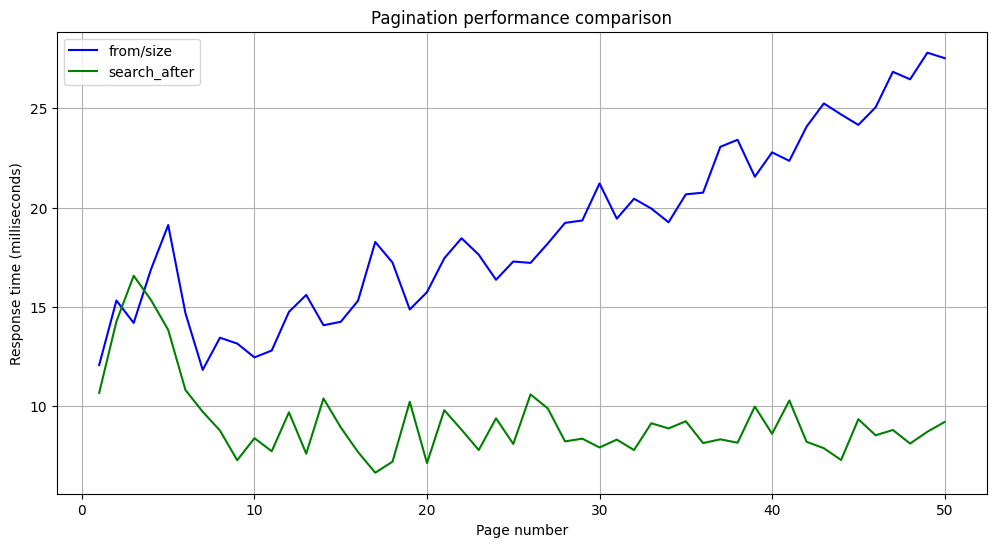

In [36]:
import matplotlib.pyplot as plt


def plot_comparison(from_size_timings, search_after_timings):
    plt.figure(figsize=(12, 6))

    pages_from_size, times_from_size = zip(*from_size_timings)
    pages_search_after, times_search_after = zip(*search_after_timings)

    plt.plot(pages_from_size, times_from_size, 'b-', label='from/size')
    plt.plot(pages_search_after, times_search_after,
             'g-', label='search_after')

    plt.xlabel('Page number')
    plt.ylabel('Response time (milliseconds)')
    plt.title('Pagination performance comparison')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_comparison(from_size_timings, search_after_timings)